In [1]:
%%capture
!pip install diffusers transformers accelerate torch torchvision

from diffusers import StableDiffusionPipeline
import torch
from PIL import Image

def generate_image(prompt, model_id="CompVis/stable-diffusion-v1-4", save_path="generated_image.png"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pipe = StableDiffusionPipeline.from_pretrained(model_id).to(device)
    image = pipe(prompt).images[0]
    image.save(save_path)
    return image

prompt = "A futuristic cityscape with flying cars at sunset"
image = generate_image(prompt)
image.show()


KeyboardInterrupt: 

Enter a text description: Cat


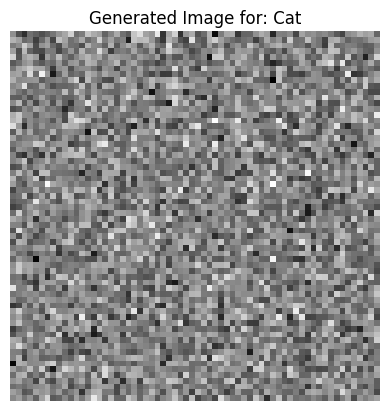

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Simple Text Encoder (LSTM)
class TextEncoder(nn.Module):
    def __init__(self, vocab_size=5000, embed_dim=256, hidden_dim=128):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, text):
        x = self.embedding(text)
        _, (hidden, _) = self.lstm(x)
        return hidden.squeeze(0)

# Generator Model
class Generator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=128, img_dim=64*64):
        super(Generator, self).__init__()
        self.fc = nn.Linear(noise_dim + text_dim, 256)
        self.gen = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, img_dim),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):
        x = torch.cat((noise, text_embedding), dim=1)
        return self.gen(self.fc(x))

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, img_dim=64*64, text_dim=128):
        super(Discriminator, self).__init__()
        self.fc = nn.Linear(img_dim + text_dim, 256)
        self.disc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img, text_embedding):
        x = torch.cat((img, text_embedding), dim=1)
        return self.disc(self.fc(x))

# Initialize models
noise_dim = 100
text_dim = 128
img_dim = 64*64  # Example: 64x64 grayscale image
text_encoder = TextEncoder()
generator = Generator(noise_dim, text_dim, img_dim)
discriminator = Discriminator(img_dim, text_dim)

# Optimizers
gen_opt = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_opt = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss Function
criterion = nn.BCELoss()

# Function to generate and show image
def generate_image(text_input):
    text_embedding = torch.randn(1, text_dim)  # Simulated embedding (replace with actual text processing)
    noise = torch.randn(1, noise_dim)

    with torch.no_grad():
        fake_image = generator(noise, text_embedding).view(64, 64).cpu().numpy()

    plt.imshow(fake_image, cmap='gray')
    plt.title(f"Generated Image for: {text_input}")
    plt.axis('off')
    plt.show()

# Take user input and generate an image
user_prompt = input("Enter a text description: ")
generate_image(user_prompt)

In [3]:
%%capture
!pip install diffusers transformers accelerate torch torchvision datasets

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from diffusers import AutoencoderKL
from transformers import CLIPTextModel, CLIPTokenizer
from torch.utils.data import DataLoader
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Pretrained Models
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Define ANN Model
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.fc6 = nn.Linear(32, 16)
        self.fc7 = nn.Linear(16, 8)
        self.fc8 = nn.Linear(8, 3 * 64 * 64)  # Image size 64x64 with 3 channels

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc5(x))
        x = torch.relu(self.fc6(x))
        x = torch.relu(self.fc7(x))
        x = torch.sigmoid(self.fc8(x))  # Normalize output
        return x.view(-1, 3, 64, 64)

model = SimpleANN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Load Sample Dataset
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
dataset = datasets.FakeData(transform=data_transform, size=100)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

# Training Loop
num_epochs = 5
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(dataloader):
        optimizer.zero_grad()
        text_inputs = tokenizer(["Sample prompt"], return_tensors="pt").input_ids.to(device)
        text_features = text_encoder(text_inputs).last_hidden_state.mean(dim=1)
        outputs = model(text_features)
        loss = criterion(outputs, images.to(device))
        loss.backward()
        optimizer.step()
        print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

# Generate an Image
def generate_image(prompt, save_path="generated_image.png"):
    text_inputs = tokenizer([prompt], return_tensors="pt").input_ids.to(device)
    text_features = text_encoder(text_inputs).last_hidden_state.mean(dim=1)
    with torch.no_grad():
        image = model(text_features)
    image = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype("uint8")
    img = Image.fromarray(image)
    img.save(save_path)
    return img

prompt = "A simple sunny landscape"
image = generate_image(prompt)
image.show()


KeyboardInterrupt: 

In [3]:
!pip install diffusers torch transformers

from diffusers import StableDiffusionPipeline
import torch

def generate_image(prompt):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to(device)
    image = pipe(prompt).images[0]
    image.show()

prompt = "A cute cartoon cat wearing sunglasses"
generate_image(prompt)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-4-25df3311a25b>", line 13, in <cell line: 0>
    generate_image(prompt)
  File "<ipython-input-4-25df3311a25b>", line 9, in generate_image
    image = pipe(prompt).images[0]
            ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py", line 1078, in __call__
    image = self.vae.decode(latents / self.vae.config.scaling_factor, return_dict=False, generator=generator)[
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/di

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-4-25df3311a25b>", line 13, in <cell line: 0>
    generate_image(prompt)
  File "<ipython-input-4-25df3311a25b>", line 9, in generate_image
    image = pipe(prompt).images[0]
            ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py", line 1078, in __call__
    image = self.vae.decode(latents / self.vae.config.scaling_factor, return_dict=False, generator=generator)[
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/di

TypeError: object of type 'NoneType' has no len()

In [1]:
from diffusers import StableDiffusionPipeline
import torch

# Load the Stable Diffusion model from Hugging Face
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

# Generate an image based on a text prompt
prompt = "A scenic landscape with mountains and lakes"
image = pipe(prompt).images[0]

# Save the generated image to a file
image.save("generated_image.png")
image.show()  # Display the image


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]